In [1]:
%run ../python/chebyshevMPT.py
from pprint import pprint
from numpy import linspace

order = 5
chebym = ChebyshevMPT(order)
u = [-1, -0.999, -0.0001, 0, 0.0001, 0.999, 1]
pprint(vars(chebym))
# Coefficients should sum to zero across regions
print('Coefficient sums:', sum(chebym.c),sum(chebym.s))

print([chebym.S(u1) for u1 in u])
#extrema = [-math.cos(math.pi*k/order) for k in range(order+1)]
#print(extrema)
#print(chebym.S(extrema))



{'c': [1.0,
       -2.618033988749895,
       3.23606797749979,
       -2.6180339887498953,
       1.0000000000000009],
 'extrema': [-1.0,
             -0.8090169943749475,
             -0.30901699437494745,
             0.30901699437494734,
             0.8090169943749473,
             1.0],
 'norm': 3.23606797749979,
 'order': 5,
 's': [-3.077683537175254,
       1.9021130325903075,
       -2.220446049250313e-16,
       -1.902113032590307,
       3.0776835371752536],
 'xi': 1}
Coefficient sums: 4.440892098500626e-16 -2.220446049250313e-16
[-1.0, -0.8613962218031653, -0.00032360679775023105, -2.220446049250313e-16, 0.00032360679774967593, 0.8613962218031643, 1.0]


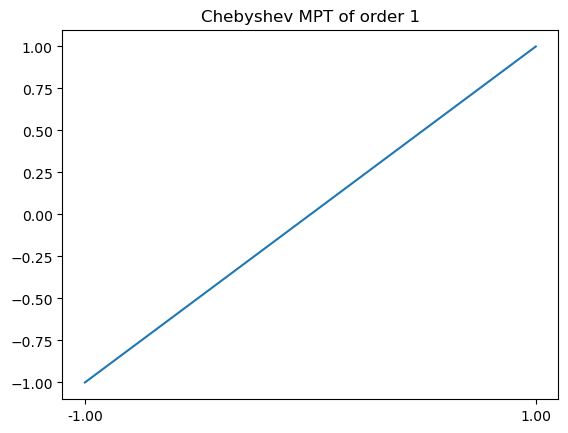

In [5]:
import matplotlib.pyplot as plt

order = 1
chebym = ChebyshevMPT(order)
u = linspace(-1.0,1.0,num=1000, endpoint=True)
S = [chebym.S(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,S)
ax.set_title(f"Chebyshev MPT of order {order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()
#plt.plot(u, y1, label='S1', color='red', linestyle='--')


In [36]:
order = 3
extrema = [-math.cos(math.pi*k/order) for k in range(order+1)]
print(extrema)
#ku = [math.acos(-u1)*order/math.pi for u1 in extrema]
#Suu = [(-1) ** (order+round(k)) for k in ku]
#print(Suu)



[-1.0, -0.5000000000000001, 0.4999999999999998, 1.0]


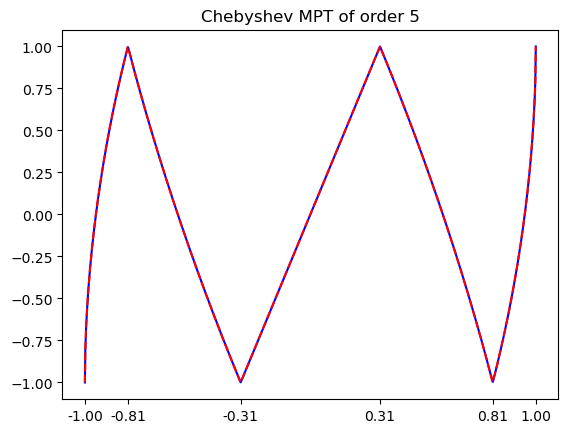

In [37]:
m = 5
chebym = ChebyshevMPT(m)
# const, rot = rotateCoef(chebym.coefficients)
# print(const)
# print(rot)

# Try closed form
# xi = 2 - (m % 2)
# const1 = xi/math.sin(xi*math.pi/(2*m))
# ell = [xi*math.floor(k/xi) for k in range(m)]
# rot1 = [(math.pi/2)*(xi/m -1) + math.pi*j/m for j in ell]
# print(const1)
# print(rot1)

u = linspace(-1.0,1.0,num=1000, endpoint=True)
S = [chebym.S(u1) for u1 in u]
S2 = [chebym.Scm(u1) for u1 in u]
fig, ax = plt.subplots()
ax.plot(u,S, label='S', color='blue')
ax.plot(u, S2, label='cm', color='red', linestyle="--")
ax.set_title(f"Chebyshev MPT of order {chebym.order}")
ax.set_xticks(chebym.extrema)
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()

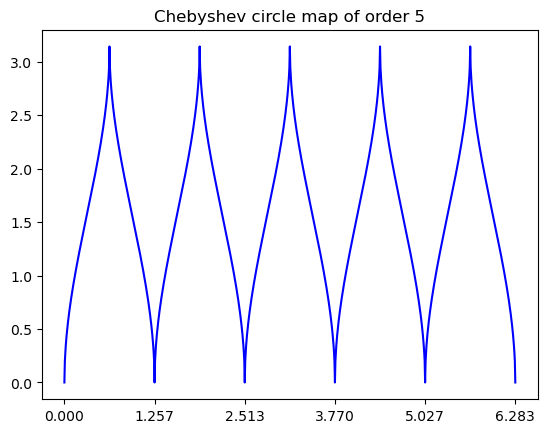

In [38]:
# Just some dumb ideas. u and chebym defined in above cell
theta = linspace(0,2*math.pi,num=1001, endpoint=True)  
psi = [math.acos(chebym.circlemap(t)) for t in theta]
xticks = linspace(0,2*math.pi,num=m+1, endpoint=True)
fig, ax = plt.subplots()
ax.plot(theta,psi, label='psi', color='blue')
ax.set_title(f"Chebyshev circle map of order {chebym.order}")
ax.set_xticks(xticks)
#extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
#ax.set_xticklabels(extrstr)
plt.show()

In [39]:
# Trying to simplify the sign rotations in the coefficients

m = 10

roots = [-math.cos(math.pi*(k+0.5)/m) for k in range(m)]

def sgnsinwj(uk, m):
    wjm = [math.acos(uk) + math.pi*2*j/m for j in range(m)]
    return [sgn(math.sin(wjm[j])) for j in range(m)]

s0 = [sgnsinwj(roots[k],m) for k in range(m)]
print(s0)

# def sgnsimp1(k, m):
#     wjm = [math.pi*( 1 - (k+0.5)/m + 2*j/m) for j in range(m)]
#     return [sgn(math.sin(wjm[j])) for j in range(m)]

# s1 = [sgnsimp1(k,m) for k in range(m)]
# print(s1)

# def sgnsimp2(k, m):
#     wjm = [(k+0.5) - 2*j for j in range(m)]
#     return [sgn(math.sin(math.pi*wjm[j]/m)) for j in range(m)]

# s2 = [sgnsimp2(k,m) for k in range(m)]
# print(s2)

def sgnsimp3(k, m):
    wjm = [(k+0.5) - 2*j for j in range(m)]
    return [int((-1)**math.floor(wjm[j]/m)) for j in range(m)]

s3 = [sgnsimp3(k,m) for k in range(m)]
print(s3)

print(chebyCoef(m))

# if (m % 2):
#     print(chebyCoefmark3odd(m))
# else:
#     print(chebyCoefmark3even(m))

print(chebyCoefmark4(m))

# Does this work for first two terms?
#print(0, 1, -1/math.tan(math.pi/(2*m)))
#print(1, 1/math.tan(math.pi/(2*m))*math.sin(math.pi/m) + math.cos(math.pi/m), -1/math.tan(math.pi/(2*m))*math.cos(math.pi/m) + math.sin(math.pi/m))

[[1, -1, -1, -1, -1, -1, 1, 1, 1, 1], [1, -1, -1, -1, -1, -1, 1, 1, 1, 1], [1, 1, -1, -1, -1, -1, -1, 1, 1, 1], [1, 1, -1, -1, -1, -1, -1, 1, 1, 1], [1, 1, 1, -1, -1, -1, -1, -1, 1, 1], [1, 1, 1, -1, -1, -1, -1, -1, 1, 1], [1, 1, 1, 1, -1, -1, -1, -1, -1, 1], [1, 1, 1, 1, -1, -1, -1, -1, -1, 1], [1, 1, 1, 1, 1, -1, -1, -1, -1, -1], [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]]
[[1, -1, -1, -1, -1, -1, 1, 1, 1, 1], [1, -1, -1, -1, -1, -1, 1, 1, 1, 1], [1, 1, -1, -1, -1, -1, -1, 1, 1, 1], [1, 1, -1, -1, -1, -1, -1, 1, 1, 1], [1, 1, 1, -1, -1, -1, -1, -1, 1, 1], [1, 1, 1, -1, -1, -1, -1, -1, 1, 1], [1, 1, 1, 1, -1, -1, -1, -1, -1, 1], [1, 1, 1, 1, -1, -1, -1, -1, -1, 1], [1, 1, 1, 1, 1, -1, -1, -1, -1, -1], [1, 1, 1, 1, 1, -1, -1, -1, -1, -1]]
([2.0, -2.0, 5.23606797749979, -5.23606797749979, 6.47213595499958, -6.47213595499958, 5.236067977499791, -5.236067977499791, 2.0000000000000018, -2.0000000000000018], [-6.155367074350508, 6.155367074350508, -3.804226065180615, 3.804226065180615, -4.44089209

NameError: name 'chebyCoefmark4' is not defined

In [5]:
# Preimage of S

m = 1
chebym = ChebyshevMPT(m)
y = 0  # S(x) to invert
# xi = 2 - (m % 2)
# w = y+ xi - 1
# const = xi/math.sin(xi*math.pi/(2*m))
# z = math.asin(w/const)
# x = [math.cos(math.pi*(1/2 + math.floor(kappa/xi))*xi/m - ((-1)**kappa)*z) for kappa in range(m)]
# Sx = [chebym.Scm(x1) for x1 in x]
# print(x)
# print(Sx)
x = chebym.Sinverse(y)
print(x)
print([chebym.Scm(x1) for x1 in x])

# Now check derivative
# xi = 2 - (m % 2)
# const = xi/math.sin(xi*math.pi/(2*m))
# theta = math.acos(y)
# kappa = math.floor(theta*m/math.pi)
# rot = math.pi*(1/2 + math.floor(kappa/xi))*xi/m
# dSdx = ((-1)**kappa)*const*math.cos(rot - theta)/math.sin(theta)
# dSdxnum = (chebym.Scm(y+0.001)-chebym.Scm(y-0.001))/0.002
# print(dSdx, dSdxnum, chebym.Scmprime(y))

p = [chebym.Scmprime(x1) for x1 in x]
print(p)
print(sum([1/abs(p1) for p1 in p]))      

[6.123233995736766e-17]
[0.0]
[1.0]
1.0


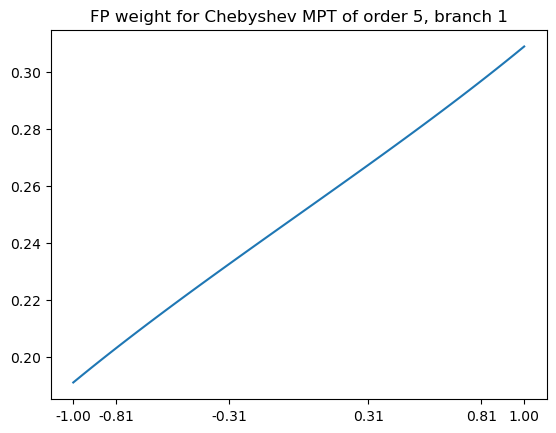

In [21]:
# Plot S'(z_k(x)) for fixed k in {0,...,m-1}

m = 5
k = 1
chebym = ChebyshevMPT(m)
u = linspace(-1.0+1e-4,1.0-1e-4,num=50, endpoint=True)
#u = [-0.8, -0.6, 0.4, 0.7]
y = [1/abs(chebym.Scmprime(chebym.Sinverse(u1)[k])) for u1 in u]

fig, ax = plt.subplots()
ax.plot(u,y)
ax.set_title(f"FP weight for Chebyshev MPT of order {m}, branch {k}")
ax.set_xticks(chebym.extrema)
#ax.set_yscale("log")
extrstr = ["{:.2f}".format(x) for x in chebym.extrema]
ax.set_xticklabels(extrstr)
plt.show()